# Pseudo Cryo-ET Data Generation from Membrane Mesh
This notebook demonstrates how to:
1. Load Mem3DG-generated membrane mesh data (`data/raw/biconcave.nc`).
2. Generate pseudo cryo-ET data.
3. Save and visualize the output.


In [1]:
import sys
from pathlib import Path

# Get the absolute path of the project root (one level above notebooks/)
project_root = Path().resolve().parent

# Add "src/" to sys.path
sys.path.append(str(project_root / "src"))

Pseudo cryo-ET data saved to: ../data/synthetic/wedge/multi_a005_w30_t60.mrc


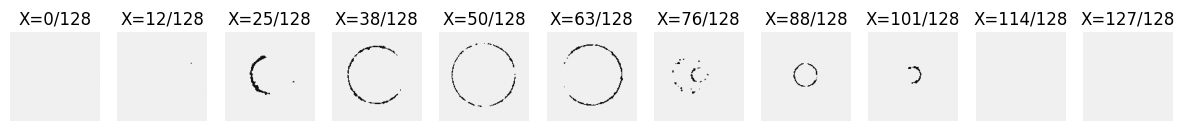

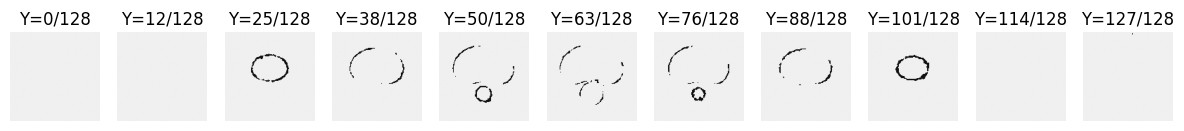

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from data_generation.mesh_to_cryoet import generate_pseudo_cryoet, plot_single_slice, plot_multiple_slices


#### Parameters ####
shape="multi"
sigma=1
flip_ratio=0.05
# missing_ratio=0.9
axis_angle=30
tilt_max=60

#### Path to Mem3DG-generated trajectory file ####
if shape == "biconcave":
    input_file = "../data/raw/biconcave.nc"
elif shape == "bud_04":
    input_file = "../data/raw/bud.nc"
elif shape == "multi":
    input_file_1 = "../data/raw/oblate.nc"
    input_file_2 = "../data/raw/sphere.nc"


#### Path to save the output cryo-ET data ####
# output_file = None
# output_file = f"../data/synthetic/{shape}.mrc"
# output_file = "../data/synthetic/test.mrc"
# output_file = f"../data/synthetic/combine/{shape}_a{str(flip_ratio).replace('.', '')}_m{str(missing_ratio).replace('.', '')}.mrc"
output_file = f"../data/synthetic/wedge/{shape}_a{str(flip_ratio).replace('.', '')}_w{axis_angle:02d}_t{tilt_max:02d}.mrc"


#### Generate pseudo cryo-ET volume ####

# for biconcave
# pseudo_cryoET = generate_pseudo_cryoet(input_file, output_file, grid_size=128, sigma=sigma)
# pseudo_cryoET = generate_pseudo_cryoet(input_file, output_file, grid_size=128, sigma=sigma, additive_noise=flip_ratio, missing_ratio=missing_ratio)
# pseudo_cryoET = generate_pseudo_cryoet(input_file, output_file, grid_size=128, sigma=sigma, additive_noise=flip_ratio, missing_wedge=True, axis_angle=axis_angle, tilt_max=tilt_max)

# for bud_04
# pseudo_cryoET = generate_pseudo_cryoet(input_file, output_file, grid_size=128, sigma=sigma, frame=36, margin_ratio=-0.4)
# pseudo_cryoET = generate_pseudo_cryoet(input_file, output_file, grid_size=128, sigma=sigma, frame=36, margin_ratio=-0.4, additive_noise=flip_ratio, missing_ratio=missing_ratio)
# pseudo_cryoET = generate_pseudo_cryoet(input_file, output_file, grid_size=128, sigma=sigma, frame=36, margin_ratio=-0.4, additive_noise=flip_ratio, missing_wedge=True, axis_angle=axis_angle, tilt_max=tilt_max)

# for multi
# pseudo_cryoET = generate_pseudo_cryoet([input_file_1, input_file_2], output_file, grid_size=128, sigma=sigma, frame=-1, margin_ratio=0.4)
# pseudo_cryoET = generate_pseudo_cryoet([input_file_1, input_file_2], output_file, grid_size=128, sigma=sigma, frame=-1, margin_ratio=0.4, additive_noise=flip_ratio, missing_ratio=missing_ratio)
pseudo_cryoET = generate_pseudo_cryoet([input_file_1, input_file_2], output_file, grid_size=128, sigma=sigma, frame=-1, margin_ratio=0.4, additive_noise=flip_ratio, missing_wedge=True, axis_angle=axis_angle, tilt_max=tilt_max)

# for experiment
# pseudo_cryoET = generate_pseudo_cryoet(input_file, output_file, grid_size=128, sigma=sigma, frame=-1, margin_ratio=0.1, flip_ratio=0, missing_wedge=False, remove_edge=True) 

thre = None
thre = 0.8

# # Visualize the middle slice in different directions
# fig, axes = plt.subplots(1, 2, figsize=(8, 4))
# plot_single_slice(pseudo_cryoET, ax=axes[0], axis='x', thre=thre)  # X-direction
# plot_single_slice(pseudo_cryoET, ax=axes[1], axis='y', thre=thre)  # Y-direction
# # plot_single_slice(pseudo_cryoET, axis='z', thre=thre)  # Z-direction

# plt.tight_layout()
# plt.show()

pseudo_cryoET = (pseudo_cryoET - np.min(pseudo_cryoET)) / (np.max(pseudo_cryoET) - np.min(pseudo_cryoET))

plot_multiple_slices(pseudo_cryoET, axis='x', num_slices=11, thre=thre)
plot_multiple_slices(pseudo_cryoET, axis='y', num_slices=11, thre=thre)

# test_data = np.where(pseudo_cryoET > thre, 1, 0)
# test_data[64, :, :]

In [ ]:
from data_generation.mesh_to_cryoet import plot_multiple_slices
import mrcfile
from pinn.cryoet_io import load_mrc_data

# shape="biconcave"
# missing_ratio=0.998
# flip_ratio=0.0
# wedge_axis="z"
# sigma = 5
# hetero_scale=1
GRID_SIZE = 64

# output_file = "../data/synthetic/biconcave.mrc"
# output_file = "../data/synthetic/bud.mrc"
# output_file = "../data/synthetic/multi.mrc"
# output_file = f"../data/synthetic/biconcave_fragment_{str(missing_ratio).replace('.', '')}.mrc"
# output_file = f"../data/synthetic/biconcave_noisy_{str(flip_ratio).replace('.', '')}.mrc"
# output_file = f"../data/synthetic/biconcave_blur_{str(sigma).replace('.', '')}.mrc"
# output_file = f"../data/synthetic/biconcave_patch_{num_patch}_{rad_patch}.mrc"
# output_file = "../data/synthetic/biconcave_test.mrc"
# output_file = "../data/synthetic/test.mrc"

# output_file = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}.mrc"
# output_file = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}_w{wedge_axis}.mrc"

output_file = f"../data/synthetic/combine/{shape}_a{str(flip_ratio).replace('.', '')}_m{str(missing_ratio).replace('.', '')}.mrc"

# output_file = f"../data/synthetic/hetero/{shape}_h{hetero_scale}.mrc"

# output_file = f"../data/experimental/downsampled/TS_105_7.mrc"

# output_file = "../data/synthetic/spine.mrc"


# Load pseudo cryo-ET data
# with mrcfile.open(output_file, permissive=True) as mrc:
    # volume = mrc.data
volume = load_mrc_data(output_file, grid_size=GRID_SIZE)

# Correct function call
thre = 0.8
# thre = None
plot_multiple_slices(volume, axis='x', num_slices=11, thre=thre)
plot_multiple_slices(volume, axis='y', num_slices=11, thre=thre)


In [3]:
# measure length

import numpy as np
from netCDF4 import Dataset

# Path to Mem3DG-generated trajectory file
input_file = "../data/raw/biconcave.nc"
data = Dataset(input_file, 'r')


# Access the 'Trajectory' group
coords = data.groups['Trajectory'].variables['coordinates'][-1]
coords = coords.reshape(-1, 3)

min_bound = np.min(coords, axis=0)
max_bound = np.max(coords, axis=0)
extent = max_bound - min_bound

print("x-length = ", extent[0])
print("y-length = ", extent[1])
print("z-length = ", extent[2])


x-length =  2.37126752123156
y-length =  2.37008613382773
z-length =  0.9744919523084066


In [3]:
## loop 

import numpy as np
import matplotlib.pyplot as plt
from data_generation.mesh_to_cryoet import generate_pseudo_cryoet, plot_single_slice, plot_multiple_slices


#### Parameters ####
shape="multi"
sigma=1
flip_ratio=0.1
# axis_angle_list=[40]
# tilt_max_list=[60, 50]
axis_angle_list=list(range(0, 91, 10))
# axis_angle_list=list(range(50, 91, 10))
tilt_max_list = list(range(90, 49, -10))

#### Path to Mem3DG-generated trajectory file ####
if shape == "biconcave":
    input_file = "../data/raw/biconcave.nc"
elif shape == "bud_04":
    input_file = "../data/raw/bud.nc"
elif shape == "multi":
    input_file_1 = "../data/raw/oblate.nc"
    input_file_2 = "../data/raw/sphere.nc"

for axis_angle in axis_angle_list:
    for tilt_max in tilt_max_list:

        #### Path to save the output cryo-ET data ####
        output_file = f"../data/synthetic/wedge/{shape}_a{str(flip_ratio).replace('.', '')}_w{axis_angle:02d}_t{tilt_max:02d}.mrc"
                
        #### Generate pseudo cryo-ET volume ####        
        if shape == "biconcave":
            pseudo_cryoET = generate_pseudo_cryoet(input_file, output_file, grid_size=128, sigma=sigma, additive_noise=flip_ratio, missing_wedge=True, axis_angle=axis_angle, tilt_max=tilt_max)
        elif shape == "bud_04":
            pseudo_cryoET = generate_pseudo_cryoet(input_file, output_file, grid_size=128, sigma=sigma, frame=36, margin_ratio=-0.4, additive_noise=flip_ratio, missing_wedge=True, axis_angle=axis_angle, tilt_max=tilt_max)
        elif shape == "multi":        
            pseudo_cryoET = generate_pseudo_cryoet([input_file_1, input_file_2], output_file, grid_size=128, sigma=sigma, frame=-1, margin_ratio=0.4, additive_noise=flip_ratio, missing_wedge=True, axis_angle=axis_angle, tilt_max=tilt_max)

        # #### Visualization ####
        # pseudo_cryoET = (pseudo_cryoET - np.min(pseudo_cryoET)) / (np.max(pseudo_cryoET) - np.min(pseudo_cryoET))
        # plot_multiple_slices(pseudo_cryoET, axis='x', num_slices=11, thre=thre)
        # plot_multiple_slices(pseudo_cryoET, axis='y', num_slices=11, thre=thre)


Pseudo cryo-ET data saved to: ../data/synthetic/wedge/multi_a01_w50_t90.mrc
Pseudo cryo-ET data saved to: ../data/synthetic/wedge/multi_a01_w50_t80.mrc
Pseudo cryo-ET data saved to: ../data/synthetic/wedge/multi_a01_w50_t70.mrc
Pseudo cryo-ET data saved to: ../data/synthetic/wedge/multi_a01_w50_t60.mrc
Pseudo cryo-ET data saved to: ../data/synthetic/wedge/multi_a01_w50_t50.mrc
Pseudo cryo-ET data saved to: ../data/synthetic/wedge/multi_a01_w60_t90.mrc
Pseudo cryo-ET data saved to: ../data/synthetic/wedge/multi_a01_w60_t80.mrc
Pseudo cryo-ET data saved to: ../data/synthetic/wedge/multi_a01_w60_t70.mrc
Pseudo cryo-ET data saved to: ../data/synthetic/wedge/multi_a01_w60_t60.mrc
Pseudo cryo-ET data saved to: ../data/synthetic/wedge/multi_a01_w60_t50.mrc
Pseudo cryo-ET data saved to: ../data/synthetic/wedge/multi_a01_w70_t90.mrc
Pseudo cryo-ET data saved to: ../data/synthetic/wedge/multi_a01_w70_t80.mrc
Pseudo cryo-ET data saved to: ../data/synthetic/wedge/multi_a01_w70_t70.mrc
Pseudo cryo-